# 04 Final Model and Submission

**Phase 5.** This notebook loads the frozen final model and produces `eval/evaluation_results.csv` with the unchanged `evaluate_agent` of the instruction notebook. It runs top to bottom from the saved model; nothing is trained here.

**Final model**: EXP-12 as an ensemble of 20 DQN networks (seeds 0 to 19), frozen with `scripts/freeze_final_model.py`:

| Component | Setting | Evidence |
|---|---|---|
| Algorithm | DQN with target network and experience replay (TD3), greedy action on the average Q-values of 20 networks | ensembles: EXP-13, EXP-14, ensemble size curve |
| Discount | γ = 0.9 (horizon about 10 h) | EXP-05: overestimation 0.035 → 0.003 |
| Training data | 2023-04-01 to 2026-06-17 (3.2 gap-free years), random-start episodes of 720 steps | EXP-02, EXP-03: memorisation removed |
| Features | mean-reversion set (last-hour candle, volume, 4h return, distance to 24h average, RSI 14h), z-score fitted on dev-train | feature analysis, EXP-09 |
| Training reward | log return minus 0.0005 per unit of position change (training only; eval uses the default reward) | EXP-12, ensemble size curve |
| Positions | [-1, 0, 0.5, 1, 2] (unchanged) | |

How it was chosen: `EXPERIMENTS.md` (all selection on the validation period 2026-06-17 to 2026-08-17).

In [1]:
import os
import sys
import json
import glob
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from rl_trading.train import prepare_splits
from rl_trading.envs import make_env, make_validation_envs
from rl_trading.agents import load_ensemble
from rl_trading.evaluate import validate, evaluate_agent

FINAL = ROOT / "models" / "final"
EVAL_DIR = ROOT / "eval"
FIG_DIR = ROOT / "figures"
pd.set_option("display.width", 160)

## 1. Load the frozen model and rebuild its data pipeline

The eval split goes through exactly the same pipeline as training: the same features and the z-score statistics fitted on dev-train. I check that the statistics recomputed now equal the ones frozen with the model.

In [2]:
with open(FINAL / "config.json") as f:
    config = json.load(f)
agent, metadata = load_ensemble(FINAL / "ensemble.pt")
splits, stats = prepare_splits(config)

with open(FINAL / "normalizer.json") as f:
    frozen_stats = json.load(f)
assert stats == metadata["normalizer"] == frozen_stats, "normalisation differs"
print(f"model: {metadata['exp_id']}, {len(agent.agents)} networks (seeds {metadata['seeds'][0]} to {metadata['seeds'][-1]}), "
      f"frozen on {metadata['frozen_on']}")
print(f"features: {[c for c in splits['eval'].columns if 'feature' in c]}")

Downloaded data: 30,528 candles, 2023-03-25 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours
dev_train: 28,152 candles, 2023-04-01 00:00:00+00:00 to 2026-06-16 23:00:00+00:00; no missing hours
val: 1,464 candles, 2026-06-17 00:00:00+00:00 to 2026-08-16 23:00:00+00:00; no missing hours
eval: 744 candles, 2026-08-17 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours
model: exp12_mr_turnover_penalty, 20 networks (seeds 0 to 19), frozen on 2026-09-28
features: ['feature_ret_4h', 'feature_dist_sma_24h', 'feature_rsi_14h', 'feature_close', 'feature_high', 'feature_low', 'feature_volume']


## 2. Validation result of the final model (the evidence it was chosen on)

In [3]:
val_envs = make_validation_envs(splits["val"], positions=config["positions"])
val_summary, _ = validate(agent, val_envs, num_episodes=10)
show = val_summary[["steps", "portfolio_return", "market_return", "excess_return", "sharpe", "max_drawdown",
                    "n_changes"] + [c for c in val_summary.columns if c.startswith("share_pos_")]]
show.round(4)

,steps,portfolio_return,market_return,excess_return,sharpe,max_drawdown,n_changes,share_pos_-1,share_pos_0,share_pos_0.5,share_pos_1,share_pos_2
env,,,,,,,,,,,,
val,1463,0.1128,-0.0426,0.1554,3.5520,-0.0386,289.5,0.0075,0.7842,0.1837,0.0075,0.0171
val_w1,743,0.0817,-0.0269,0.1086,4.3777,-0.0386,147.5,0.0121,0.8564,0.1046,0.0000,0.0269
val_w2,743,0.0267,-0.0154,0.0421,2.2329,-0.0269,147.9,0.0027,0.7131,0.2600,0.0148,0.0094


### Why is the ensemble mostly flat?

Q-values of all 20 networks on the validation states along the ensemble's greedy path: how much the networks disagree per action, and which action wins.

In [4]:
import torch

env = make_env(splits["val"], positions=config["positions"])
np.random.seed(0)
obs, _ = env.reset()
states, done, truncated = [], False, False
while not (done or truncated):
    states.append(np.array(obs, dtype=np.float32))
    obs, _, done, truncated, _ = env.step(agent.choose_action_eval(obs))
with torch.no_grad():
    x = torch.as_tensor(np.stack(states))
    q = torch.stack([member.q_network(x) for member in agent.agents]).numpy()   # (networks, states, actions)

n_actions = len(config["positions"])
pd.DataFrame({
    "std of Q across the 20 networks": q.std(axis=0).mean(axis=0),
    "ensemble mean Q": q.mean(axis=0).mean(axis=0),
    "chosen by the ensemble": np.bincount(q.mean(axis=0).argmax(axis=1), minlength=n_actions) / len(states),
    "chosen by a single network (average)": [np.mean(q.argmax(axis=2) == a) for a in range(n_actions)],
}, index=pd.Index(config["positions"], name="position")).round(4)

,std of Q across the 20 networks,ensemble mean Q,chosen by the ensemble,chosen by a single network (average)
position,,,,
-1.0,0.0070,0.0026,0.0075,0.1015
0.0,0.0019,0.0094,0.7840,0.4068
0.5,0.0021,0.0088,0.1839,0.2623
1.0,0.0042,0.0058,0.0075,0.1201
2.0,0.0105,-0.0010,0.0171,0.1093


The networks disagree least about flat (no market exposure: its immediate reward is almost certain) and increasingly more about the exposed positions, most about 2x. Averaging shrinks the exposed actions towards their common mean, which after fees and the turnover penalty lies below flat, so flat wins by default: the ensemble is flat in about 78% of states, a single network in about 41%. This shrinkage is what makes the ensemble trade less, and also why it cannot follow a trend.

Benchmarks on the full validation period: buy and hold -4.27%, always short +4.24%, flat 0%, random -18.2%. Baseline (EXP-00): -5.83% ± 4.33%.

## 3. Final evaluation on the eval month (run once)

`evaluate_agent` is the unchanged function of the instruction notebook (verified line by line in `rl_trading/evaluate.py`). The eval env uses the course's fees and borrow rate and the default log-return reward. `np.random` is seeded only to make the random initial positions reproducible.

In [5]:
env_eval = make_env(splits["eval"], positions=config["positions"], verbose=1)
np.random.seed(0)
eval_dir = Path(os.path.relpath(EVAL_DIR))   # relative path in the printed log
results = evaluate_agent(agent, env_eval, num_episodes=10, render=True,
                         csv_path=eval_dir / "evaluation_results.csv",
                         renderer_logs_dir=eval_dir / "render_logs")
results

Market Return : 21.12%   |   Portfolio Return : -2.09%   |   
Eval Episode 1: Total Reward: -0.02, Portfolio Return: -2.09%, Market Return: 21.12%, Excess Return: -23.21%, Steps: 743
Market Return : 21.12%   |   Portfolio Return : -2.23%   |   
Eval Episode 2: Total Reward: -0.02, Portfolio Return: -2.23%, Market Return: 21.12%, Excess Return: -23.35%, Steps: 743
Market Return : 21.12%   |   Portfolio Return : -2.23%   |   
Eval Episode 3: Total Reward: -0.02, Portfolio Return: -2.23%, Market Return: 21.12%, Excess Return: -23.35%, Steps: 743
Market Return : 21.12%   |   Portfolio Return : -2.23%   |   
Eval Episode 4: Total Reward: -0.02, Portfolio Return: -2.23%, Market Return: 21.12%, Excess Return: -23.35%, Steps: 743
Market Return : 21.12%   |   Portfolio Return : -2.23%   |   
Eval Episode 5: Total Reward: -0.02, Portfolio Return: -2.23%, Market Return: 21.12%, Excess Return: -23.35%, Steps: 743
Market Return : 21.12%   |   Portfolio Return : -2.22%   |   
Eval Episode 6: Total R

,episode,portfolio_return,market_return,excess_return,steps,total_reward
0,1,-0.0209,0.2112,-0.2321,743,-0.021107
1,2,-0.0223,0.2112,-0.2335,743,-0.022584
2,3,-0.0223,0.2112,-0.2335,743,-0.022584
3,4,-0.0223,0.2112,-0.2335,743,-0.022584
4,5,-0.0223,0.2112,-0.2335,743,-0.022584
5,6,-0.0222,0.2112,-0.2334,743,-0.022484
6,7,-0.0223,0.2112,-0.2335,743,-0.022584
7,8,-0.0223,0.2112,-0.2335,743,-0.022534
8,9,-0.0209,0.2112,-0.2321,743,-0.021107
9,10,-0.0223,0.2112,-0.2335,743,-0.022584


In [6]:
# Sanity checks of the submission file
csv = pd.read_csv(EVAL_DIR / "evaluation_results.csv")
assert len(csv) == 10, "expected 10 episodes"
assert (csv["steps"] == 743).all(), "every episode must cover 743 steps"
assert np.allclose(csv["total_reward"], np.log1p(csv["portfolio_return"]), atol=1e-4), "reward inconsistent"
print(f"10 episodes, 743 steps each, no bankruptcy")
print(f"mean portfolio_return {csv['portfolio_return'].mean():+.2%} (min {csv['portfolio_return'].min():+.2%}, "
      f"max {csv['portfolio_return'].max():+.2%}), mean market_return {csv['market_return'].mean():+.2%}, "
      f"mean excess_return {csv['excess_return'].mean():+.2%}")

10 episodes, 743 steps each, no bankruptcy
mean portfolio_return -2.20% (min -2.23%, max -2.09%), mean market_return +21.12%, mean excess_return -23.32%


## 4. Comparison with the baseline (post hoc)

The baseline evaluation ran once on 2026-09-28, before any optimisation, with seed 0 fixed in advance as the official baseline CSV. The other two baseline seeds are shown for context.

In [7]:
rows = [{"model": "final (EXP-12, 20-network ensemble)", "file": "evaluation_results.csv"},
        {"model": "baseline EXP-00 seed 0 (official)", "file": "baseline_evaluation_results.csv"},
        {"model": "baseline EXP-00 seed 1", "file": "baseline_seed1_evaluation_results.csv"},
        {"model": "baseline EXP-00 seed 2", "file": "baseline_seed2_evaluation_results.csv"}]
for row in rows:
    df = pd.read_csv(EVAL_DIR / row["file"])
    row.update({"portfolio_return": df["portfolio_return"].mean(), "market_return": df["market_return"].mean(),
                "excess_return": df["excess_return"].mean()})
comparison = pd.DataFrame(rows).set_index("model")
comparison[["portfolio_return", "market_return", "excess_return"]].map(lambda v: f"{v:+.2%}")

,portfolio_return,market_return,excess_return
model,,,
"final (EXP-12, 20-network ensemble)",-2.20%,+21.12%,-23.32%
baseline EXP-00 seed 0 (official),+22.61%,+21.12%,+1.49%
baseline EXP-00 seed 1,+23.52%,+21.12%,+2.40%
baseline EXP-00 seed 2,+13.20%,+21.12%,-7.92%


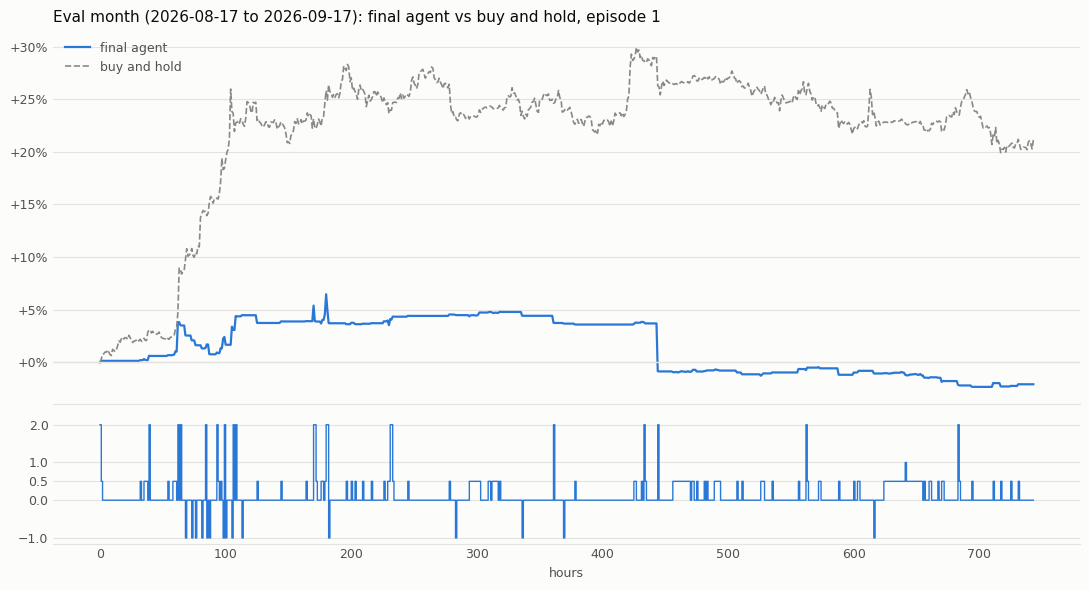

In [8]:
# Equity curve of the final agent on the eval month, from the render log of the first evaluation episode
log_file = sorted(glob.glob(str(EVAL_DIR / "render_logs" / "*.pkl")))[-10]
episode = pd.read_pickle(log_file)
equity = episode["portfolio_valuation"] / episode["portfolio_valuation"].iloc[0] - 1
market = episode["close"] / episode["close"].iloc[0] - 1

SURF, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
fig, axes = plt.subplots(2, 1, figsize=(11, 6), facecolor=SURF, sharex=True, gridspec_kw=dict(height_ratios=[3, 1]))
for ax in axes:
    ax.set_facecolor(SURF)
    for side in ["top", "right", "left"]:
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.grid(axis="y", color=GRID, lw=0.8)
    ax.tick_params(colors=INK2, labelsize=9, length=0)
axes[0].plot(equity.to_numpy() * 100, color="#2a78d6", lw=1.6, label="final agent")
axes[0].plot(market.to_numpy() * 100, color="#8a8984", lw=1.2, ls="--", label="buy and hold")
axes[0].axhline(0, color=GRID, lw=1)
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:+.0f}%"))
axes[0].legend(frameon=False, fontsize=9, labelcolor=INK2, loc="upper left")
axes[0].set_title("Eval month (2026-08-17 to 2026-09-17): final agent vs buy and hold, episode 1", loc="left", color=INK, fontsize=11)
axes[1].step(np.arange(len(episode)), episode["position"].to_numpy(), where="post", color="#2a78d6", lw=1)
axes[1].set_yticks(config["positions"])
axes[1].set_xlabel("hours", color=INK2, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "phase5_eval_equity.png", dpi=150, facecolor=SURF)
plt.show()

## 5. Post hoc: all main models on the eval month (not used for selection)

The final model was frozen and submitted before this comparison. It shows how strongly the eval result depends on the market regime: the eval month rose 21%, while the validation period moved sideways.

In [9]:
from rl_trading.agents import load_agent, EnsembleAgent
from rl_trading.evaluate import ConstantAgent, RandomAgent, summarize_experiment

RUNS = ROOT / "runs"
POS = config["positions"]
pipelines = {}

def envs_for(exp_id):
    # eval and validation envs through the data pipeline of that experiment
    if exp_id not in pipelines:
        with open(RUNS / exp_id / "seed_0" / "config.json") as f:
            cfg = json.load(f)
        s, _ = prepare_splits(cfg)
        pipelines[exp_id] = {"eval": make_env(s["eval"], positions=cfg["positions"]),
                             "val": make_validation_envs(s["val"], positions=cfg["positions"])["val"]}
    return pipelines[exp_id]

def ret(agent, env):
    summary, _ = validate(agent, {"x": env}, num_episodes=10)
    return summary.loc["x", "portfolio_return"], summary.loc["x", "share_pos_1"] + summary.loc["x", "share_pos_2"]

rows = []
base_envs = envs_for("baseline")
for label, make_agent in [("buy and hold", lambda: ConstantAgent(POS, 1)), ("always short", lambda: ConstantAgent(POS, -1)),
                          ("flat", lambda: ConstantAgent(POS, 0)), ("random", lambda: RandomAgent(len(POS), seed=0))]:
    # a fresh agent per period, so the random agent draws the same numbers as in notebook 01
    (e, long_share), (v, _) = ret(make_agent(), base_envs["eval"]), ret(make_agent(), base_envs["val"])
    rows.append({"model": label, "kind": "benchmark", "val": v, "eval": e, "long share on eval": long_share})

for exp_id, label, seeds in [("baseline", "baseline EXP-00", range(3)), ("exp05_gamma09", "EXP-05 γ 0.9", range(6)),
                             ("exp09_mr_features", "EXP-09 MR features", range(20)),
                             ("exp12_mr_turnover_penalty", "EXP-12 MR + penalty", range(20))]:
    envs = envs_for(exp_id)
    agents = [load_agent(RUNS / exp_id / f"seed_{s}" / "last.pt") for s in seeds]
    singles = [ret(a, envs["eval"]) for a in agents]
    _, per_seed = summarize_experiment(RUNS / exp_id, seeds=seeds)
    rows.append({"model": f"{label} ({len(agents)} single networks)", "kind": "single mean",
                 "val": per_seed[per_seed["env"] == "val"]["portfolio_return"].mean(),
                 "eval": np.mean([s[0] for s in singles]), "long share on eval": np.mean([s[1] for s in singles])})
    if len(agents) >= 6:
        ensemble = EnsembleAgent(agents)
        (e, long_share), (v, _) = ret(ensemble, envs["eval"]), ret(ensemble, envs["val"])
        rows.append({"model": f"{label} (ensemble of {len(agents)})", "kind": "final" if exp_id == "exp12_mr_turnover_penalty" else "ensemble",
                     "val": v, "eval": e, "long share on eval": long_share})

posthoc = pd.DataFrame(rows)
posthoc.to_csv(EVAL_DIR / "posthoc_eval_comparison.csv", index=False)
posthoc.set_index("model").round(4)

Downloaded data: 9,672 candles, 2025-08-10 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours
dev_train: 7,296 candles, 2025-08-17 00:00:00+00:00 to 2026-06-16 23:00:00+00:00; no missing hours
val: 1,464 candles, 2026-06-17 00:00:00+00:00 to 2026-08-16 23:00:00+00:00; no missing hours
eval: 744 candles, 2026-08-17 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours
Downloaded data: 30,528 candles, 2023-03-25 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours
dev_train: 28,152 candles, 2023-04-01 00:00:00+00:00 to 2026-06-16 23:00:00+00:00; no missing hours
val: 1,464 candles, 2026-06-17 00:00:00+00:00 to 2026-08-16 23:00:00+00:00; no missing hours
eval: 744 candles, 2026-08-17 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours
Downloaded data: 30,528 candles, 2023-03-25 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours
dev_train: 28,152 candles, 2023-04-01 00:00:00+00:00 to 2026-06-16 23:00:00+00:00; no missing hours
val: 1,464 can

,kind,val,eval,long share on eval
model,,,,
buy and hold,benchmark,-0.0427,0.2111,1.0000
always short,benchmark,0.0424,-0.2113,0.0000
flat,benchmark,-0.0001,-0.0001,0.0000
random,benchmark,-0.1821,0.0870,0.3948
baseline EXP-00 (3 single networks),single mean,-0.0583,0.1978,0.4706
EXP-05 γ 0.9 (6 single networks),single mean,-0.0268,0.1401,0.6660
EXP-05 γ 0.9 (ensemble of 6),ensemble,0.0007,0.1366,0.9690
EXP-09 MR features (20 single networks),single mean,-0.0930,-0.0519,0.2984
EXP-09 MR features (ensemble of 20),ensemble,0.0215,-0.0755,0.0242


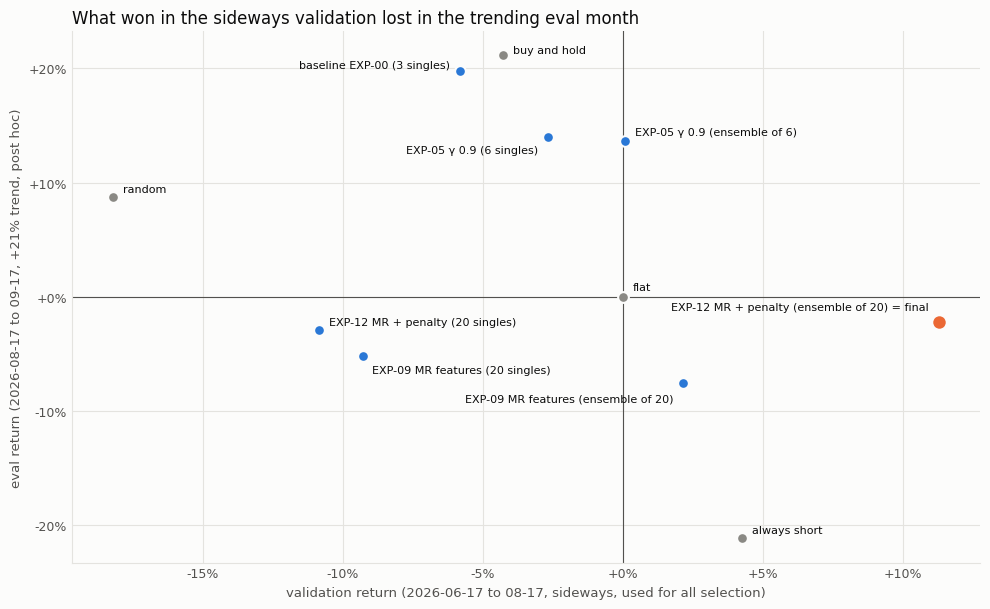

In [10]:
colors = {"benchmark": "#8a8984", "single mean": "#2a78d6", "ensemble": "#2a78d6", "final": "#eb6834"}
fig, ax = plt.subplots(figsize=(10, 6.2), facecolor=SURF)
ax.set_facecolor(SURF)
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
for side in ["left", "bottom"]:
    ax.spines[side].set_color(GRID)
ax.grid(color=GRID, lw=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors=INK2, labelsize=9, length=0)
ax.axhline(0, color=INK2, lw=0.8)
ax.axvline(0, color=INK2, lw=0.8)
offsets = {"buy and hold": (7, 2), "baseline EXP-00 (3 single networks)": (-7, 2), "EXP-05 γ 0.9 (6 single networks)": (-7, -12),
           "EXP-05 γ 0.9 (ensemble of 6)": (7, 4), "flat": (7, 5), "EXP-09 MR features (ensemble of 20)": (-7, -13),
           "EXP-09 MR features (20 single networks)": (7, -12), "EXP-12 MR + penalty (20 single networks)": (7, 4),
           "EXP-12 MR + penalty (ensemble of 20)": (-7, 9)}
for _, r in posthoc.iterrows():
    ax.scatter(r["val"], r["eval"], s=110 if r["kind"] == "final" else 60, color=colors[r["kind"]], zorder=3, edgecolor=SURF, lw=1.5)
    dx, dy = offsets.get(r["model"], (7, 4))
    label = r["model"].replace(" single networks", " singles") + (" = final" if r["kind"] == "final" else "")
    ax.annotate(label, (r["val"], r["eval"]), xytext=(dx, dy), textcoords="offset points", fontsize=8, color=INK,
                ha="left" if dx > 0 else "right")
pct = FuncFormatter(lambda v, _: f"{v:+.0%}")
ax.xaxis.set_major_formatter(pct)
ax.yaxis.set_major_formatter(pct)
ax.set_xlabel("validation return (2026-06-17 to 08-17, sideways, used for all selection)", color=INK2, fontsize=9.5)
ax.set_ylabel("eval return (2026-08-17 to 09-17, +21% trend, post hoc)", color=INK2, fontsize=9.5)
ax.set_title("What won in the sideways validation lost in the trending eval month", loc="left", color=INK, fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "phase5_val_vs_eval.png", dpi=150, facecolor=SURF)
plt.show()

### Where does the eval result come from?

Log return by the position held (one greedy episode per period), the worst single hour, and a counterfactual in which the same policy uses 1x instead of 2x (for the analysis only).

In [11]:
from rl_trading.evaluate import rollout_with_q, run_episode


class CapLeverage:
    """Same policy with the 2x action replaced by 1x (counterfactual, analysis only)."""

    def __init__(self, agent, positions):
        self.agent, self.positions = agent, positions

    def choose_action_eval(self, state):
        action = self.agent.choose_action_eval(state)
        return self.positions.index(1) if self.positions[action] == 2 else action


rows = []
for period in ["val", "eval"]:
    np.random.seed(0)
    path = rollout_with_q(agent, make_env(splits[period], positions=POS))
    np.random.seed(0)
    capped, _ = run_episode(CapLeverage(agent, POS), make_env(splits[period], positions=POS))
    worst = path["reward"].idxmin()
    row = {"period": period, "return": np.expm1(path["reward"].sum()),
           "worst hour": path.loc[worst, "reward"], "position in worst hour": path.loc[worst, "position"],
           "return with 2x capped at 1x": capped["portfolio_return"]}
    for p in POS:
        row[f"log return while at {p:g}"] = path.loc[path["position"] == p, "reward"].sum()
    rows.append(row)
pd.DataFrame(rows).set_index("period").T.round(4)

period,val,eval
return,0.1133,-0.0209
worst hour,-0.0238,-0.0448
position in worst hour,2.0000,2.0000
return with 2x capped at 1x,0.0807,0.0001
log return while at -1,0.0081,-0.0259
log return while at 0,-0.0088,-0.0055
log return while at 0.5,0.0574,0.0169
log return while at 1,0.0022,-0.0020
log return while at 2,0.0484,-0.0047


### Did the signal survive?

Rank correlation of the mean-reversion features with the next-hour return on the 3-year dev-train, on validation and on the eval month. Noise level (2 standard errors): about ±0.012, ±0.052 and ±0.073.

In [12]:
from rl_trading.data import load_raw_data, add_default_features

raw = load_raw_data(ROOT / "data", train_start=pd.Timestamp("2023-04-01", tz="UTC"))
candles = add_default_features(raw)
log_close = np.log(candles["close"])
step = log_close.diff()
gain, loss = step.clip(lower=0).rolling(14).mean(), (-step.clip(upper=0)).rolling(14).mean()
signals = pd.DataFrame({
    "4h return": log_close.diff(4),
    "distance to 24h average": candles["close"] / candles["close"].rolling(24).mean() - 1,
    "RSI 14h": gain / (gain + loss),
    "last-hour return": candles["feature_close"],
    "168h return": log_close.diff(168),
})
next_hour = step.shift(-1)   # analysis target only
table = {}
for name, (a, b) in {"dev-train (3y)": ("2023-04-01", "2026-06-17"), "validation": ("2026-06-17", "2026-08-17"),
                     "eval month": ("2026-08-17", "2026-09-17")}.items():
    m = (candles.index >= pd.Timestamp(a, tz="UTC")) & (candles.index < pd.Timestamp(b, tz="UTC"))
    table[name] = signals[m].rank().corrwith(next_hour[m].rank())
pd.DataFrame(table).round(3)

Downloaded data: 30,528 candles, 2023-03-25 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours


,dev-train (3y),validation,eval month
4h return,-0.051,-0.060,-0.020
distance to 24h average,-0.041,-0.064,-0.003
RSI 14h,-0.030,-0.066,-0.002
last-hour return,-0.062,-0.031,-0.072
168h return,-0.006,-0.023,-0.021


## 6. Conclusions

**Ranking.** The ranking on the eval month is almost the reverse of the validation ranking. Long-leaning models (buy and hold, the baseline, EXP-05) win the trend month; the cautious mean-reversion ensembles that won the sideways validation lose slightly, and even the random agent (0.5 long on average) is ahead of the final model this month.

**Two separate effects.** Trailing buy and hold by about 23 points is structural: a strategy that is flat most of the time cannot keep up with a +21% month. Ending below zero comes from the tails: the worst hour was a 2x position before a sharp drop (about -4.5%), and contrarian shorts against the rally cost about 2.6% (log). With 2x capped at 1x, the same policy ends the eval month at about 0%, while on validation the same cap costs about 3 points (+11.3% → +8.1%). With an edge about the size of the fee, leverage mainly amplifies variance.

**Why validation overstated the edge.** The multi-hour mean-reversion signals the agent relies on were stronger on validation than on the 3-year average and are not detectable on the eval month; only the one-hour reversal remains. One month is too noisy to prove that the signal vanished, but the result is consistent with it. In addition, every selection decision used the same two validation months, so the final model's validation return (+11.28%) is optimistic: it is the best configuration found on this block, not an unbiased estimate.

**No trend information in the state.** No feature predicts trends: the 168-hour return has no correlation with the next hour in any period, including the trend month itself. The models that won the eval month were near-constant long bets (arbitrary per seed in the baseline), not trend-followers.

**What I would do differently.** Walk-forward validation over several blocks from different regimes (bull, bear, sideways), keeping only configurations that hold up in all of them; no leverage unless the measured edge clearly exceeds trading costs; and features that carry information about longer horizons if the agent is meant to profit from trends.